<a href="https://colab.research.google.com/github/katydixonx/CSCU9M6_Assignment/blob/main/CSCU9M6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSCU9M6 Sign Language Recognition Using Deep Convolutional Neural Networks
**Student number:** 3140669
**March 2026**
**GitHub:** https://github.com/katydixonx/CSCU9M6_Assignment

## 1. Setup and Imports

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.19.0
NumPy version: 2.0.2


## 2. Mount Google Drive and Load Dataset

In [166]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Deliverable 1: Data Loading and Preprocessing

### 1.1 Load the Dataset

In [167]:
# DELIVERABLE 1.1 - Load CSV files

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('/content/drive/MyDrive/SignLanguageMNIST/sign_mnist_train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/SignLanguageMNIST/sign_mnist_test.csv')


In [168]:
# Inspect the class distribution

# Count how many images per class in training set
print("=== Class Distribution in Training Set ===")
print(train_df['label'].value_counts().sort_index())

# Check unique label values
unique_labels = sorted(train_df['label'].unique())
print("\nUnique label values:", unique_labels)
print("Number of classes:", len(unique_labels))


=== Class Distribution in Training Set ===
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

Unique label values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Number of classes: 24


In [169]:
# DELIVERABLE 1.1 - Separate labels from pixel values
# reshape into (28, 28, 1) image tensors

# --- Training data ---
y_train_full = train_df['label'].values
x_train_full = train_df.drop('label', axis=1).values
# --- Test data ---
y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values


x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test        = x_test.reshape(-1, 28, 28, 1)

print("x_train_full shape:", x_train_full.shape)  # (27455, 28, 28, 1)
print("y_train_full shape:", y_train_full.shape)   # (27455,)
print("x_test shape:", x_test.shape)               # (7172, 28, 28, 1)
print("y_test shape:", y_test.shape)               # (7172,)


x_train_full shape: (27455, 28, 28, 1)
y_train_full shape: (27455,)
x_test shape: (7172, 28, 28, 1)
y_test shape: (7172,)


### 1.2 Normalise Pixel Values


In [170]:
# Convert integer pixel values (0-255) to float32 and scale to [0.0, 1.0]
x_train_full = x_train_full.astype("float32") / 255.0
x_test        = x_test.astype("float32") / 255.0

# Verify the normalisation worked
print("Pixel value BEFORE normalisation would be: 0 to 255")
print("Pixel value AFTER normalisation:")
print("  Minimum value in training set:", x_train_full.min())   # should be 0.0
print("  Maximum value in training set:", x_train_full.max())   # should be 1.0
print("  Data type:", x_train_full.dtype)                       # should be float32


Pixel value BEFORE normalisation would be: 0 to 255
Pixel value AFTER normalisation:
  Minimum value in training set: 0.0
  Maximum value in training set: 1.0
  Data type: float32


### 1.3 Validation Split

In [171]:
# Split 20% of training data into a validation set
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,       # 20% goes to validation
    random_state=42,     # ensures same split every run
    stratify=y_train_full  # keeps class proportions balanced in both sets
)

print("=== Dataset Split Summary ===")
print(f"Training samples:   {x_train.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")
print(f"Test samples:       {x_test.shape[0]}")
print(f"\nImage shape: {x_train.shape[1:]}")


=== Dataset Split Summary ===
Training samples:   21964
Validation samples: 5491
Test samples:       7172

Image shape: (28, 28, 1)


In [172]:
print("Unique labels in y_train:", sorted(np.unique(y_train)))

Unique labels in y_train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [173]:
num_classes = 25

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)
y_test_oh  = to_categorical(y_test,  num_classes)

print("y_train_oh shape:", y_train_oh.shape)   # (21964, 24)
print("\nExample — label 0 (letter A) encoded as:")
print(y_train_oh[0])   # [1. 0. 0. 0. 0. ... 0.]


y_train_oh shape: (21964, 25)

Example — label 0 (letter A) encoded as:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0.]


### 1.4 Visualise Sample Images

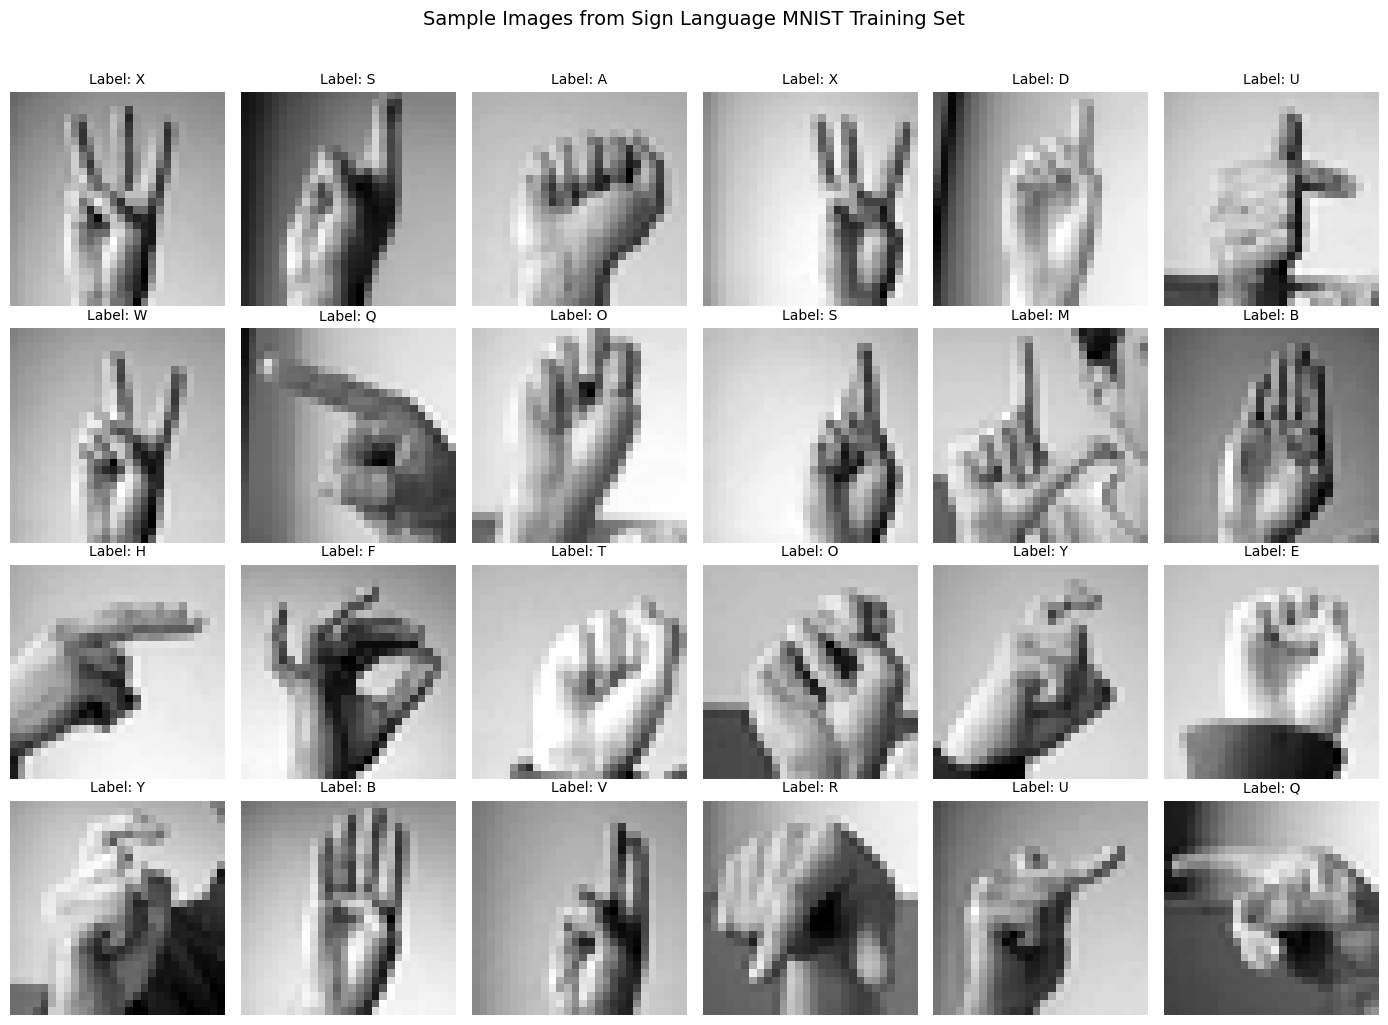

Image saved as 'sample_images.png'


In [174]:
# Map numeric labels back to letters
all_letters = [chr(65 + i) for i in range(26) if chr(65 + i) not in ['J', 'Z']]
label_to_letter = {i: letter for i, letter in enumerate(all_letters)}

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
axes = axes.flat

for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')   # reshape back to 2D for display
    ax.set_title(f"Label: {label_to_letter[y_train[i]]}", fontsize=10)
    ax.axis('off')   # hide axis tick marks

plt.suptitle("Sample Images from Sign Language MNIST Training Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')  # save for your report
plt.show()

print("Image saved as 'sample_images.png'")


In [175]:
# Final summary of preprocessed data

print("=" * 50)
print("DELIVERABLE 1 COMPLETE — DATA SUMMARY")
print("=" * 50)
print(f"\nTraining set:   {x_train.shape}  labels: {y_train.shape}")
print(f"Validation set: {x_val.shape}  labels: {y_val.shape}")
print(f"Test set:       {x_test.shape}  labels: {y_test.shape}")
print(f"\nOne-hot labels shape:  {y_train_oh.shape}")
print(f"Pixel value range:     [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Data type:             {x_train.dtype}")
print(f"Number of classes:     {num_classes}")
print("\nReady for Deliverable 2: CNN Architecture")


DELIVERABLE 1 COMPLETE — DATA SUMMARY

Training set:   (21964, 28, 28, 1)  labels: (21964,)
Validation set: (5491, 28, 28, 1)  labels: (5491,)
Test set:       (7172, 28, 28, 1)  labels: (7172,)

One-hot labels shape:  (21964, 25)
Pixel value range:     [0.0, 1.0]
Data type:             float32
Number of classes:     25

Ready for Deliverable 2: CNN Architecture


## Deliverable 2: CNN architectures

In [176]:
# Define input shape and number of classes

input_shape = (28, 28, 1)   # 28x28 grayscale images (1 channel)
num_classes = 25


### 2.1 Baseline CNN

In [177]:
# MODEL 1: Baseline CNN

baseline_model = tf.keras.Sequential([
    tf.keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation='softmax'),
])

baseline_model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,489 (3.08 MB)

 Trainable params: 806,489 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [178]:
# Compile the baseline model

baseline_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Baseline model compiled successfully")


Baseline model compiled successfully


### 2.2 Enhanced CNN — VGG-Style Architecture

In [179]:
# MODEL 2: Enhanced CNN

enhanced_model = tf.keras.Sequential([
    tf.keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax'),
])

enhanced_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,889 (956.60 KB)

 Trainable params: 244,185 (953.85 KB)

 Non-trainable params: 704 (2.75 KB)

In [180]:
# Compile the enhanced model

enhanced_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Enhanced model compiled successfully")


Enhanced model compiled successfully


In [181]:
# Print both model summaries for comparison

print("=" * 60)
print("BASELINE MODEL SUMMARY")
print("=" * 60)
baseline_model.summary()

print("\n")
print("=" * 60)
print("ENHANCED MODEL SUMMARY")
print("=" * 60)
enhanced_model.summary()


BASELINE MODEL SUMMARY


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,489 (3.08 MB)

 Trainable params: 806,489 (3.08 MB)

...

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,889 (956.60 KB)

 Trainable params: 244,185 (953.85 KB)

 Non-trainable params: 704 (2.75 KB)

## Deliverable 3: Training, Testing and Validation

### 3.1 Hyperparameter Tuning and Training

In [182]:
import time

batch_size = 64
epochs = 30

start = time.time()
history_baseline = baseline_model.fit(
    x_train, y_train_oh,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val_oh)
)
baseline_time = time.time() - start
print(f"Baseline training time: {baseline_time:.2f}s")

start = time.time()
history_enhanced = enhanced_model.fit(
    x_train, y_train_oh,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val_oh)
)
enhanced_time = time.time() - start
print(f"Enhanced training time: {enhanced_time:.2f}s")

Epoch 1/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3544 - loss: 2.1722 - val_accuracy: 0.7319 - val_loss: 1.0741
Epoch 2/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6605 - loss: 1.0562 - val_accuracy: 0.8935 - val_loss: 0.5456
Epoch 3/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7697 - loss: 0.7132 - val_accuracy: 0.9425 - val_loss: 0.3230
Epoch 4/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8293 - loss: 0.5302 - val_accuracy: 0.9698 - val_loss: 0.2168
Epoch 5/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8707 - loss: 0.3999 - val_accuracy: 0.9845 - val_loss: 0.1136
Epoch 6/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8968 - loss: 0.3233 - val_accuracy: 0.9940 - val_loss: 0.0820
Epoch 7/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9151 - loss: 0.2624 - val_accuracy: 0.9975 - val_loss: 0.0522
Epoch 8/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9296 - loss: 0.2219 - val_accuracy: 0

### 3.2 Training vs Validation Accuracy and Loss


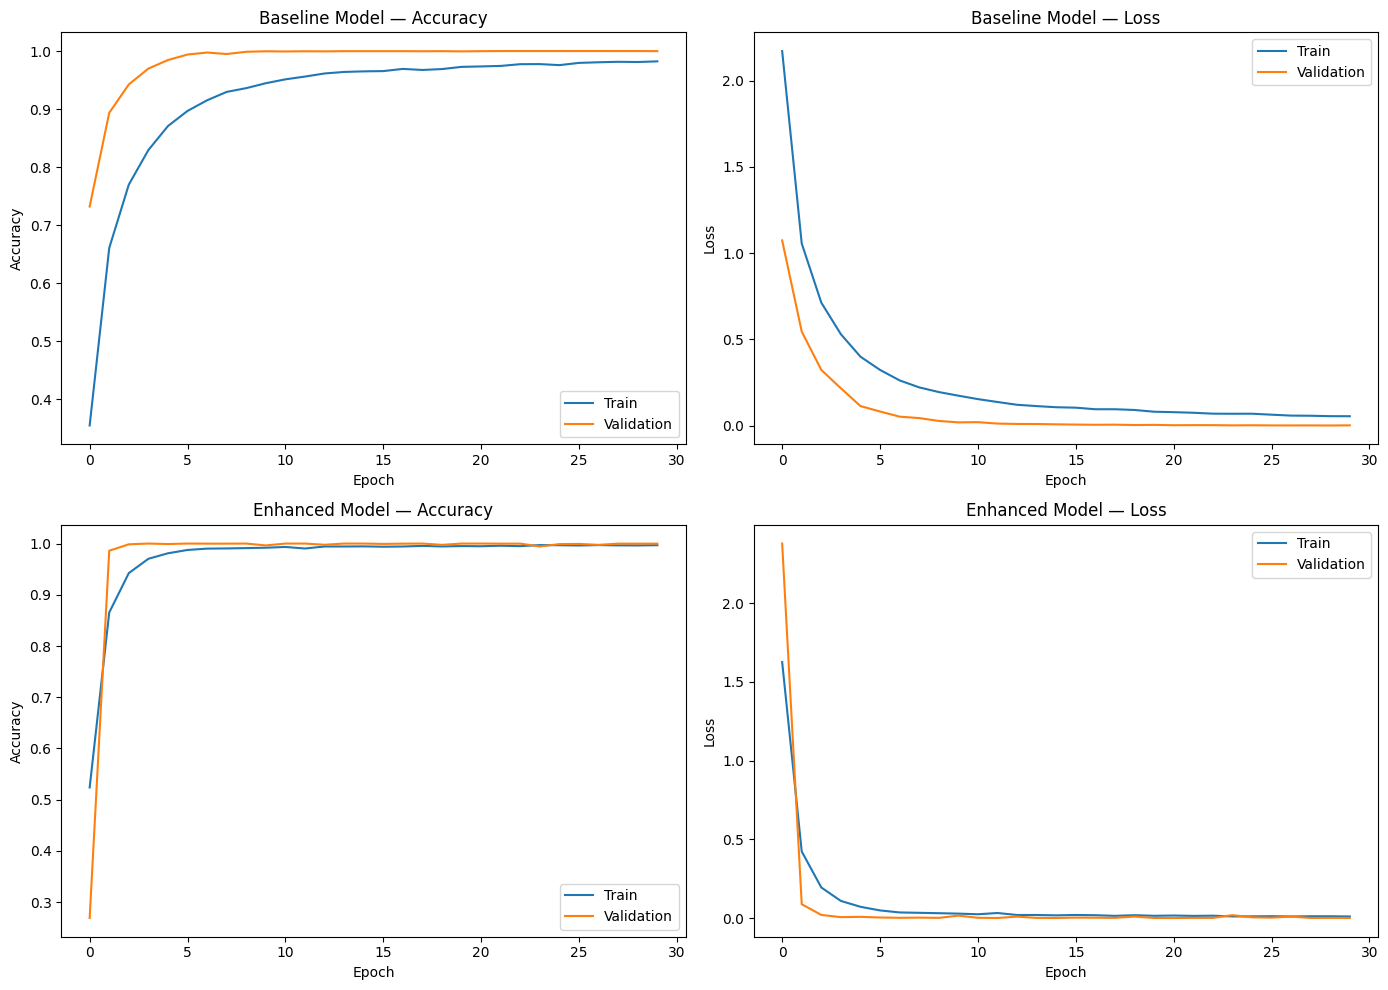

In [183]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline accuracy
axes[0, 0].plot(history_baseline.history['accuracy'], label='Train')
axes[0, 0].plot(history_baseline.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Baseline Model — Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Baseline loss
axes[0, 1].plot(history_baseline.history['loss'], label='Train')
axes[0, 1].plot(history_baseline.history['val_loss'], label='Validation')
axes[0, 1].set_title('Baseline Model — Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Enhanced accuracy
axes[1, 0].plot(history_enhanced.history['accuracy'], label='Train')
axes[1, 0].plot(history_enhanced.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('Enhanced Model — Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# Enhanced loss
axes[1, 1].plot(history_enhanced.history['loss'], label='Train')
axes[1, 1].plot(history_enhanced.history['val_loss'], label='Validation')
axes[1, 1].set_title('Enhanced Model — Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [184]:
baseline_loss, baseline_acc = baseline_model.evaluate(x_test, y_test_oh, verbose=0)
enhanced_loss, enhanced_acc = enhanced_model.evaluate(x_test, y_test_oh, verbose=0)

baseline_params = baseline_model.count_params()
enhanced_params = enhanced_model.count_params()

print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Enhanced':>12}")
print("=" * 55)
print(f"{'Test Accuracy':<25} {baseline_acc:>11.4f} {enhanced_acc:>11.4f}")
print(f"{'Test Loss':<25} {baseline_loss:>11.4f} {enhanced_loss:>11.4f}")
print(f"{'Parameters':<25} {baseline_params:>12,} {enhanced_params:>12,}")
print(f"{'Training Time (s)':<25} {baseline_time:>11.1f} {enhanced_time:>11.1f}")
print("=" * 55)

Metric                        Baseline     Enhanced
Test Accuracy                  0.8613      0.9762
Test Loss                      0.7367      0.0703
Parameters                     806,489      244,889
Training Time (s)                47.7        71.2


### 3.3 Confusion Matrix


In [185]:
y_pred_baseline = baseline_model.predict(x_test)
y_pred_enhanced = enhanced_model.predict(x_test)

y_pred_baseline_labels = np.argmax(y_pred_baseline, axis=1)
y_pred_enhanced_labels  = np.argmax(y_pred_enhanced,  axis=1)
y_test_labels = np.argmax(y_test_oh, axis=1)


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


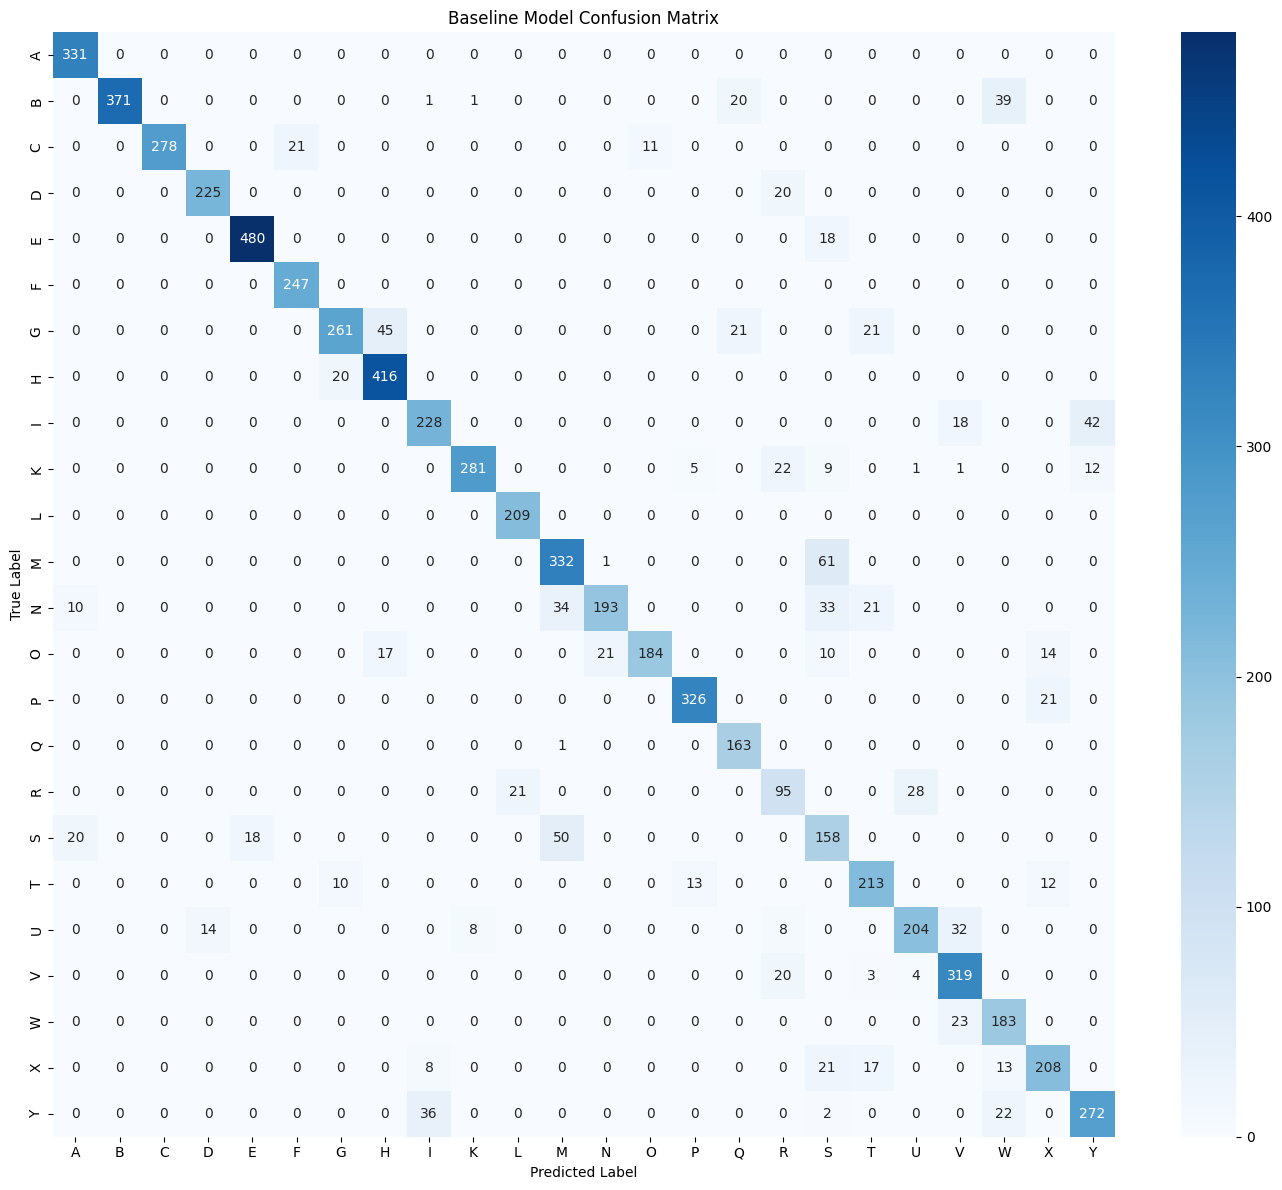

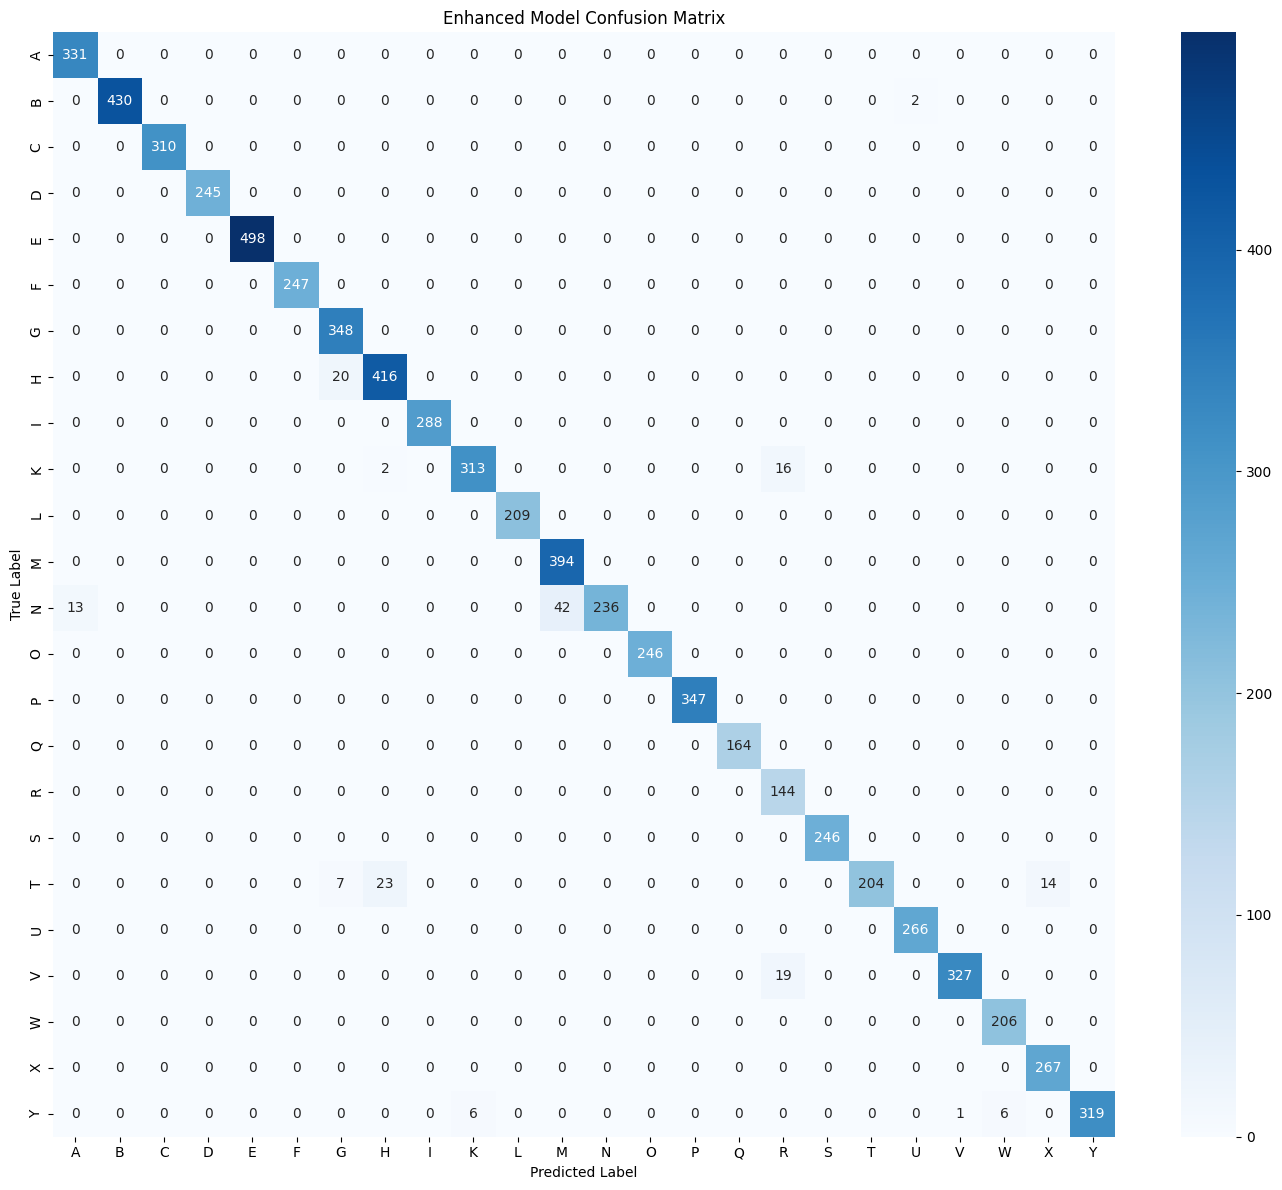

In [186]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_letters = [chr(65 + i) for i in range(26) if chr(65 + i) not in ['J', 'Z']]

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

cm_baseline = confusion_matrix(y_test_labels, y_pred_baseline_labels)
cm_enhanced  = confusion_matrix(y_test_labels, y_pred_enhanced_labels)

plot_confusion_matrix(cm_baseline, all_letters, 'Baseline Model Confusion Matrix')
plot_confusion_matrix(cm_enhanced,  all_letters, 'Enhanced Model Confusion Matrix')


### 3.4 Classification Report and Sample Predictions


In [187]:
from sklearn.metrics import classification_report
import numpy as np

labels_present = np.arange(24)

print("Baseline Model — Classification Report")
print(classification_report(y_test_labels, y_pred_baseline_labels,
                            labels=labels_present,
                            target_names=all_letters))

print("Enhanced Model — Classification Report")
print(classification_report(y_test_labels, y_pred_enhanced_labels,
                            labels=labels_present,
                            target_names=all_letters))

Baseline Model — Classification Report
              precision    recall  f1-score   support

           A       0.92      1.00      0.96       331
           B       1.00      0.86      0.92       432
           C       1.00      0.90      0.95       310
           D       0.94      0.92      0.93       245
           E       0.96      0.96      0.96       498
           F       0.92      1.00      0.96       247
           G       0.90      0.75      0.82       348
           H       0.87      0.95      0.91       436
           I       0.84      0.79      0.81       288
           K       0.00      0.00      0.00         0
           L       0.97      0.85      0.90       331
           M       0.91      1.00      0.95       209
           N       0.80      0.84      0.82       394
           O       0.90      0.66      0.76       291
           P       0.94      0.75      0.83       246
           Q       0.95      0.94      0.94       347
           R       0.80      0.99      0.8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

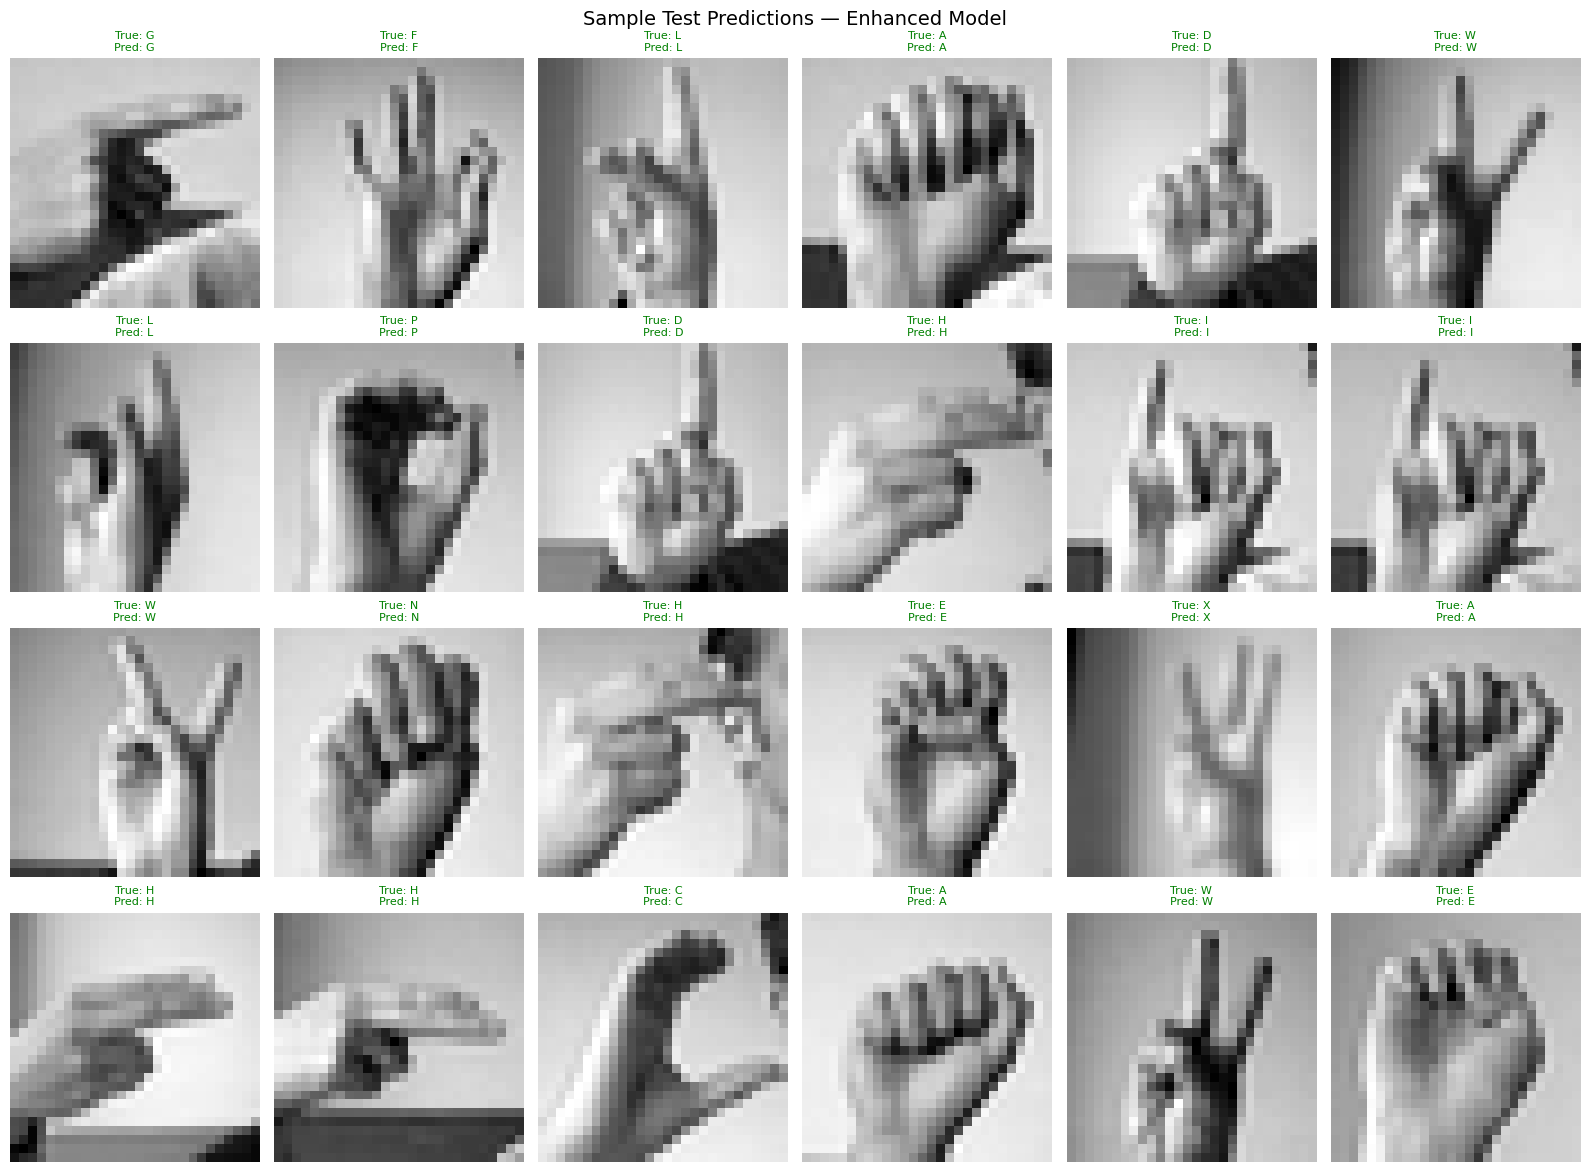

In [188]:
fig, axes = plt.subplots(4, 6, figsize=(16, 12))
axes = axes.flat

for i, ax in enumerate(axes):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    true_label      = all_letters[y_test_labels[i]]
    predicted_label = all_letters[y_pred_enhanced_labels[i]]
    correct = true_label == predicted_label
    ax.set_title(f'True: {true_label}\nPred: {predicted_label}',
                 color='green' if correct else 'red', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Test Predictions — Enhanced Model', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
